## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))

from paths import DATA_DATASETS, DATA_EMBEDDINGS

## Load Data

In [2]:
outfits = pd.read_csv(DATA_DATASETS / "outfits.csv", sep=";")
embeddings = pd.read_csv(DATA_EMBEDDINGS / "embeddings_voyage_multimodal.csv", sep=";")
transactions = pd.read_csv(DATA_DATASETS / "transactions.csv", sep=";")

Join dataframes

In [3]:
data = outfits.merge(embeddings, left_on="id", right_on="outfit_id")

In [4]:
data.head()

,id,name,description,group,owner,timeCreated,retailPrice,pricePerWeek,pricePerMonth,Brand,...,dim_2038,dim_2039,dim_2040,dim_2041,dim_2042,dim_2043,dim_2044,dim_2045,dim_2046,dim_2047
0,outfit.fffdaa715c3646f8b1c0f04d549ff07e,Out of stock - Asymmetric Frilled Dress,"This fun, short dress features and asymmetric ...",group.50a586c78eb7626e294ba3bd07d12c79,o_00053,2017-12-30T11:28:01.000000,4000.0,600.0,1200.0,Sandro,...,0.029541,0.010559,0.011230,0.043945,0.035889,-0.015442,-0.001434,0.020630,0.026001,-0.020752
1,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,Yellow Shell Mellomholmene Blouse,This beautiful blouse features an adjustable n...,group.61ad2fcabb3e9197e3836376e6b67f2c,o_00577,2021-06-07T12:07:22.921000,1300.0,590.0,1180.0,ILAG,...,0.012512,-0.005463,-0.000084,-0.006500,0.021362,-0.012939,0.011719,0.023438,0.032715,0.000610
2,outfit.fff175b13ceb453f9928625491412ede,Kaula Dress Black,Kaula from Rodebjer is a fitted dress made in ...,group.37c2b59d63d3a9c2d58e07f532f71f7f,o_00336,2023-06-05T09:17:59.004000,3100.0,930.0,1860.0,Rodebjer,...,0.031982,-0.015442,0.019409,0.034424,0.040771,-0.010620,0.004395,0.018433,0.046387,-0.027832
3,outfit.ffef9d7c292a48b69076d2df2e32352f,For sale - Jarvis Blouse,This wrap blouse has mid length sleeves and a ...,group.dfcaa57546b0b7a5e9eb204449b6cc1c,o_00030,2021-05-18T14:02:28.690000,1500.0,590.0,1180.0,Stylein,...,0.027954,0.017578,-0.001930,0.023804,-0.018677,-0.025146,-0.026367,0.020386,0.035400,0.018433
4,outfit.ffeef842238f4dbdabc6c730a75aa2bd,Black Amber Pants,"Feel slack and nice dressed with this pant, ma...",group.ee297c977905eb21a123a4aea5fbb6d2,o_00602,2021-07-16T14:02:30.643000,1200.0,590.0,1180.0,Kupong knit.wear,...,-0.006805,-0.021973,0.047607,0.013245,0.059082,-0.012878,-0.005249,-0.016724,-0.005676,0.003510


Get embedding-matrix from dataframe

In [5]:
embedding_cols = [col for col in data.columns if col.startswith("dim_")]
X = data[embedding_cols].values

In [6]:
print(np.min(X))
print(np.max(X))

-0.109375
0.125


Scaling enforces same vector length, which should stabilize semantic vectors (should try without later to check if necessary)

In [7]:
X_scaled = normalize(X)

## K-Means

Elbow method to get optimal amount of clusters:

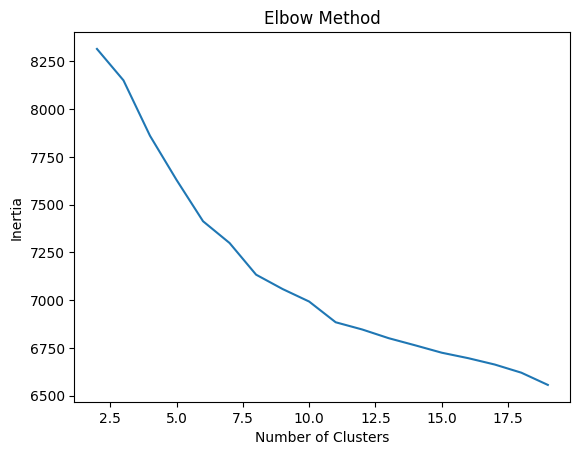

In [13]:
inertia = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

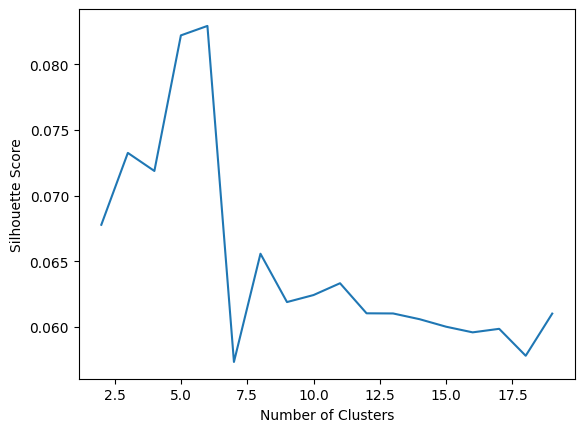

In [14]:
scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(K_range, scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [15]:
print("Best K (Elbow):", K_range[np.argmin(inertia)])
print("Best K (Silhouette):", K_range[np.argmax(scores)])

Best K (Elbow): 19
Best K (Silhouette): 6


Use 6 clusters for KMeans 

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
data["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_33332\2454298217.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["cluster"] = kmeans.fit_predict(X_scaled)


In [ ]:
cluster_summary = data.groupby("cluster")["retailPrice"].mean().sort_values()
print(cluster_summary)

cluster
4    1863.511650
1    2080.331376
5    2135.485580
2    2604.987249
6    3053.942869
3    3751.622767
0    4085.612532
Name: retailPrice, dtype: float64


In [ ]:
data["cluster"].value_counts()

cluster
2    3338
6    3031
1    2493
4    2135
3    2045
5    1729
0     878
Name: count, dtype: int64

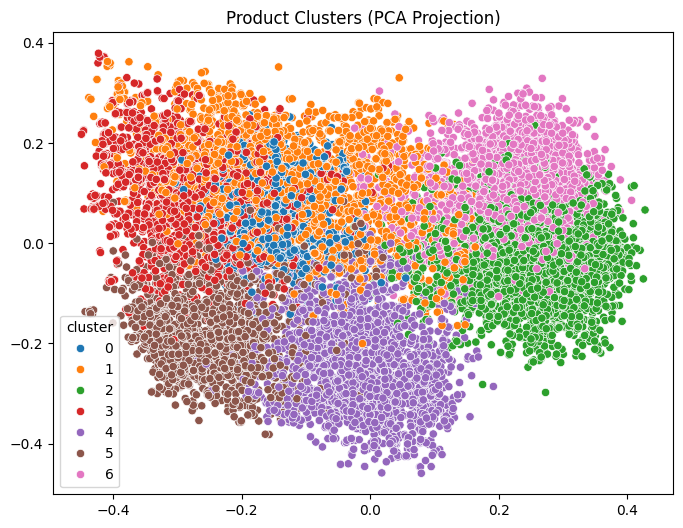

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data["cluster"], palette="tab10")
plt.title("Product Clusters (PCA Projection)")
plt.show()

In [ ]:
merged = transactions.merge(data[["id", "cluster"]], 
                            left_on="outfit.id", 
                            right_on="id")

cluster_revenue = merged.groupby("cluster").size().sort_values(ascending=False)
print(cluster_revenue)

cluster
2    15983
6    10671
4     8542
3     7490
1     7199
5     6769
0     4303
dtype: int64


## DBSCAN

In [8]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric='euclidean')
labels = clusterer.fit_predict(X_scaled)

In [9]:
np.unique(labels)

array([-1,  0,  1,  2,  3,  4])

In [10]:
noise_ratio = np.mean(labels == -1)
print("Noise ratio:", noise_ratio)

Noise ratio: 0.14333184229024218


In [11]:
pd.Series(labels).value_counts()

 3    12988
-1     2243
 2      169
 4      158
 1       52
 0       39
Name: count, dtype: int64

Super dominant cluster (ca. 84%) and 4 relatively small clusters. Noise is fine.

In [12]:
clusterer_200 = hdbscan.HDBSCAN(min_cluster_size=200, metric='euclidean')
labels_200 = clusterer_200.fit_predict(X_scaled)

In [13]:
np.unique(labels_200)

noise_ratio = np.mean(labels_200 == -1)
print("Noise ratio:", noise_ratio)

pd.Series(labels_200).value_counts()

Noise ratio: 0.8212026327560866


-1    12851
 0     2264
 1      534
Name: count, dtype: int64